# Customer Segmentation Using K-Means Clustering

Association rule mining on a small transaction dataset using `KMeans`.

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')


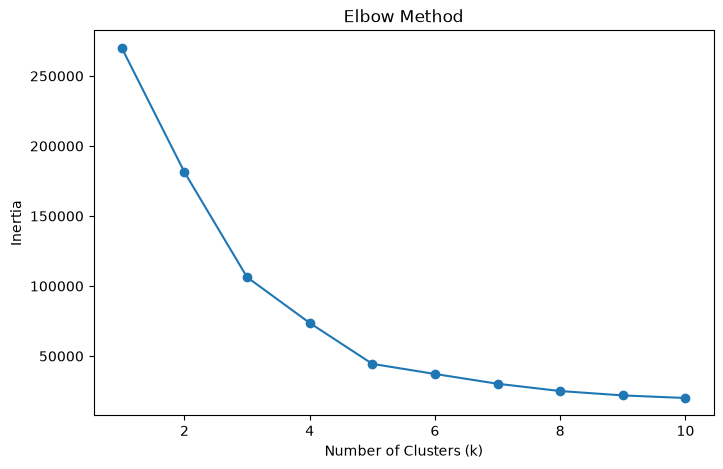

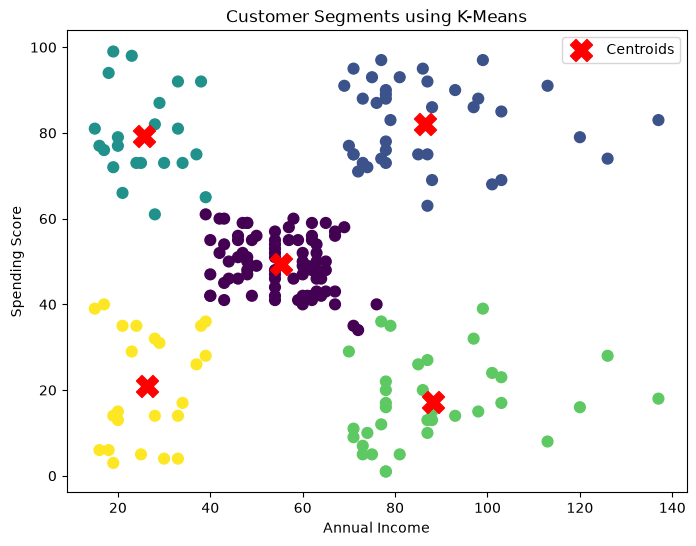

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

df = pd.read_csv("Mall_Customers.csv") #Keep the dataset in the same directory as this script or provide the full path to the file.

print(df.head())
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
print(df.columns)

inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.show()


kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X)


plt.figure(figsize=(8, 6))

plt.scatter(
    X.iloc[:, 0],
    X.iloc[:, 1],
    c=y_kmeans,
    cmap='viridis',
    s=60
)

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=250,
    c='red',
    marker='X',
    label='Centroids'
)

plt.title('Customer Segments using K-Means')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend()
plt.show()